# Predicción de Abandono de Clientes (Customer Churn) mediante Machine Learning y Agente de Utilidad para Retención

**Preparación del entorno, verificación inicial, análisis exploratorio y preprocesamiento**

Este notebook integra el trabajo correspondiente a la preparación del entorno, la carga y verificación inicial del dataset, el Análisis Exploratorio de Datos (EDA) y el preprocesamiento (limpieza, codificación, escalado y partición de datos) del proyecto *"Predicción de Abandono de Clientes mediante Machine Learning y un Agente de Utilidad para la Retención de Clientes"*.

**Contenido:**
1. Configuración inicial
2. Carga y verificación estructural del dataset
3. Análisis Exploratorio de Datos (EDA)
4. Limpieza de datos
5. Codificación de variables categóricas
6. Escalado de variables numéricas
7. Partición de datos: entrenamiento, prueba y validación cruzada
8. Conclusiones y variables disponibles para la siguiente etapa

> A partir de este punto, el proyecto continuará desarrollándose sobre este mismo notebook: cada nueva fase se añadirá como una sección adicional, en lugar de crear archivos independientes.

## 1. Configuración inicial

In [3]:
# Instalación de librerías no incluidas por defecto en el entorno de Google Colab.
# xgboost e imbalanced-learn se emplearán en el entrenamiento; shap se usará más
# adelante para la interpretabilidad del modelo final.

!pip install -q xgboost imbalanced-learn shap


In [4]:
# --- Manejo de datos ---
import pandas as pd
import numpy as np

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine Learning (se utilizarán en fases posteriores, se importan aquí por conveniencia) ---
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# --- Configuración general de visualización ---
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# --- Configuración de reproducibilidad ---
# Se fija una semilla global para garantizar que los resultados del proyecto
# sean reproducibles en ejecuciones futuras.
RANDOM_STATE = 42

print("Librerías importadas correctamente.")
print(f"Versión de pandas: {pd.__version__}")
print(f"Versión de numpy: {np.__version__}")


Librerías importadas correctamente.
Versión de pandas: 2.2.2
Versión de numpy: 2.0.2


## 2. Carga y verificación estructural del dataset

El dataset puede cargarse montando Google Drive o subiéndolo manualmente. Se documentan ambas opciones; se debe descomentar la que corresponda.

In [5]:
# ============================================================
# OPCIÓN A: Carga desde Google Drive (recomendada para trabajo colaborativo)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')
ruta_dataset = '/content/drive/MyDrive/RUTA_DEL_PROYECTO/WA_Fn-UseC_-Telco-Customer-Churn.csv'

# ============================================================
# OPCIÓN B: Carga mediante subida manual de archivo
# ============================================================
# from google.colab import files
# archivo_subido = files.upload()
# ruta_dataset = list(archivo_subido.keys())[0]

# ruta_dataset = 'WA_FnUseC_TelcoCustomerChurn.csv'  # ajustar según el entorno

df = pd.read_csv(ruta_dataset)
print(f"Dataset cargado correctamente. Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado correctamente. Dimensiones: 7043 filas x 21 columnas


In [6]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
# NOTA METODOLÓGICA: 'TotalCharges' suele cargarse como texto (object) debido a
# 11 registros con valor vacío, correspondientes a clientes con tenure = 0.
# Esta verificación es diagnóstica; la corrección formal se realiza en la Sección 4.

print(f"Tipo de dato actual de 'TotalCharges': {df['TotalCharges'].dtype}")

valores_no_numericos = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]
print(f"Cantidad de registros con 'TotalCharges' no numérico o vacío: {len(valores_no_numericos)}")

if len(valores_no_numericos) > 0:
    display(valores_no_numericos[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head(10))


Tipo de dato actual de 'TotalCharges': object
Cantidad de registros con 'TotalCharges' no numérico o vacío: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [9]:
print("Valores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [10]:
duplicados = df['customerID'].duplicated().sum()
print(f"Cantidad de customerID duplicados: {duplicados}")


Cantidad de customerID duplicados: 0


## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Distribución de la variable objetivo

In [11]:
import os
os.makedirs('/content/figuras', exist_ok=True)  # carpeta de salida para las figuras del informe


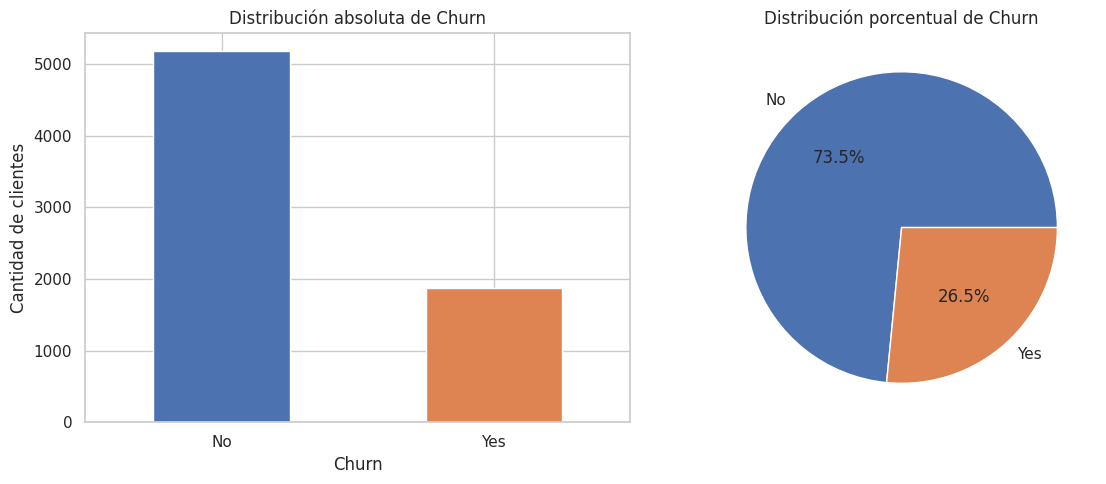

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

df['Churn'].value_counts().plot(kind='bar', ax=ax[0], color=['#4C72B0', '#DD8452'])
ax[0].set_title('Distribución absoluta de Churn')
ax[0].set_xlabel('Churn')
ax[0].set_ylabel('Cantidad de clientes')
ax[0].tick_params(axis='x', rotation=0)

df['Churn'].value_counts(normalize=True).mul(100).plot(kind='pie', ax=ax[1], autopct='%1.1f%%',
                                                          colors=['#4C72B0', '#DD8452'])
ax[1].set_title('Distribución porcentual de Churn')
ax[1].set_ylabel('')

plt.tight_layout()
plt.savefig('/content/figuras/3.1.4_a_distribucion_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print(df['Churn'].value_counts(normalize=True).round(3) * 100)


### 3.2 Variables numéricas vs. Churn

**Nota de diseño:** en una versión previa esta sección empleaba diagramas de caja (boxplots). Se reemplazan por gráficos de barras, más directos de interpretar: (a) el valor promedio de cada variable numérica según el grupo de Churn, y (b) la tasa de abandono por rango (bins), en el mismo formato de barras apiladas ya usado para las variables categóricas en la Sección 3.3. Esto mantiene un único lenguaje visual en todo el EDA.

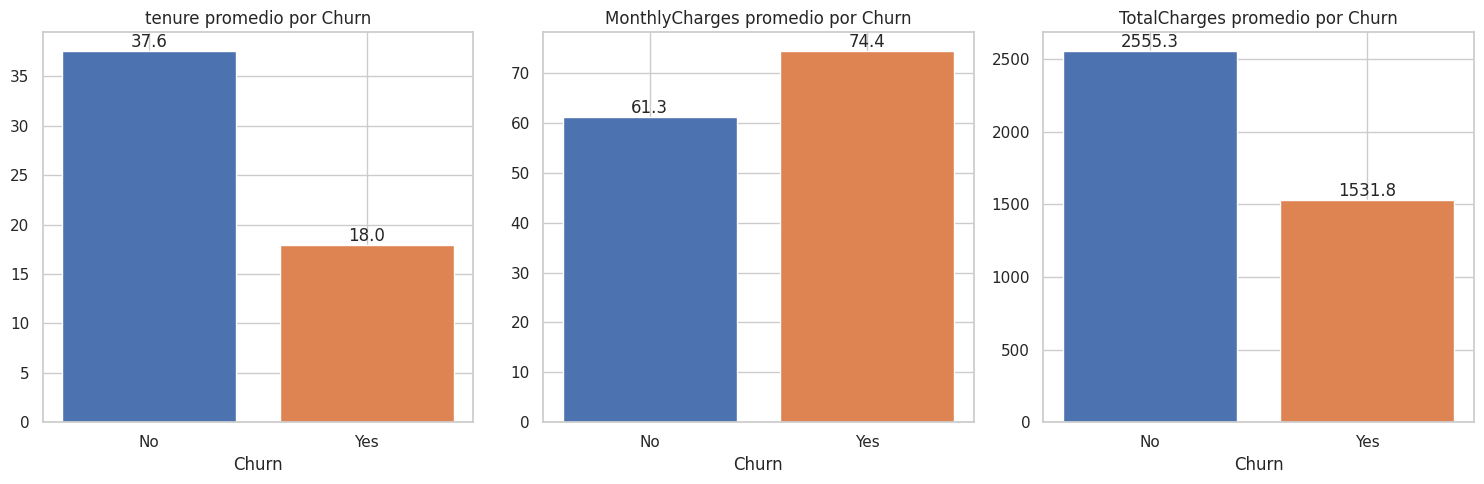

In [13]:
# (a) Valor promedio por grupo de Churn — lectura directa: una barra más alta
# en el grupo "Yes" indica que esa variable tiende a ser mayor entre quienes abandonan.
df_temp = df.copy()
df_temp['TotalCharges'] = pd.to_numeric(df_temp['TotalCharges'], errors='coerce')

variables_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges']
promedios = df_temp.groupby('Churn')[variables_numericas].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, var in enumerate(variables_numericas):
    barras = axes[i].bar(promedios.index, promedios[var], color=['#4C72B0', '#DD8452'])
    axes[i].set_title(f'{var} promedio por Churn')
    axes[i].set_xlabel('Churn')
    axes[i].bar_label(barras, fmt='%.1f')

plt.tight_layout()
plt.savefig('/content/figuras/3.1.4_b_promedio_por_churn.png', dpi=150, bbox_inches='tight')
plt.show()


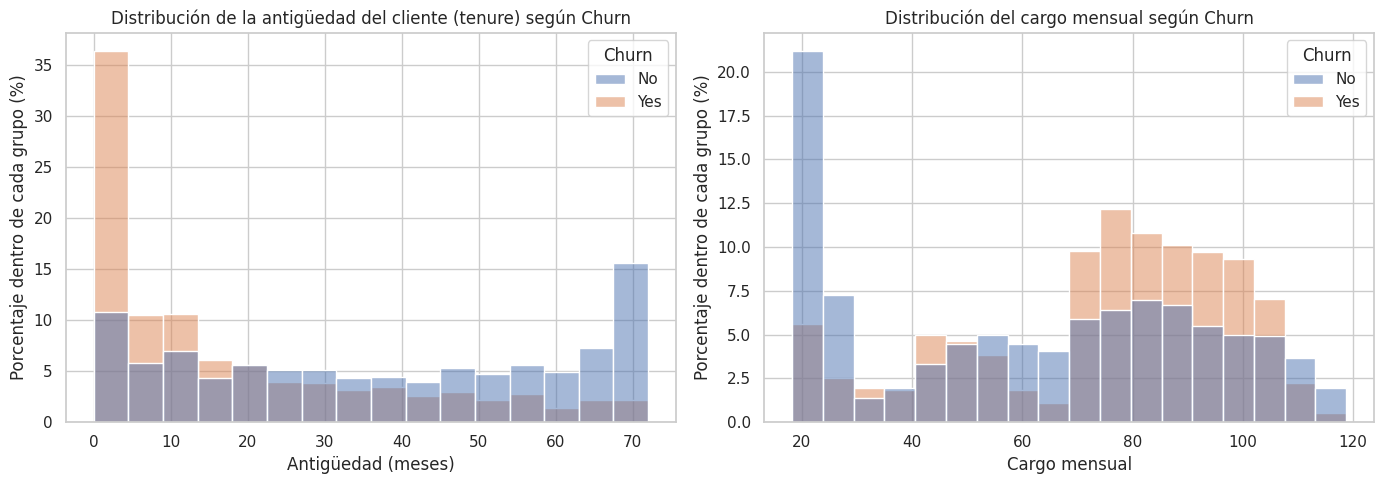

In [14]:
# Histogramas superpuestos de tenure y MonthlyCharges, separados por Churn.
# Se usa stat='percent' con common_norm=False para que ambos grupos (Yes/No)
# se muestren en la misma escala porcentual, aunque tengan distinto tamaño.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_temp, x='tenure', hue='Churn', multiple='layer', stat='percent',
             common_norm=False, alpha=0.5, ax=axes[0], palette=['#4C72B0', '#DD8452'])
axes[0].set_title('Distribución de la antigüedad del cliente (tenure) según Churn')
axes[0].set_xlabel('Antigüedad (meses)')
axes[0].set_ylabel('Porcentaje dentro de cada grupo (%)')

sns.histplot(data=df_temp, x='MonthlyCharges', hue='Churn', multiple='layer', stat='percent',
             common_norm=False, alpha=0.5, ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_title('Distribución del cargo mensual según Churn')
axes[1].set_xlabel('Cargo mensual')
axes[1].set_ylabel('Porcentaje dentro de cada grupo (%)')

plt.tight_layout()
plt.savefig('/content/figuras/3.1.4_c_distribucion_tenure_cargo.png', dpi=150, bbox_inches='tight')
plt.show()


**Lectura de los gráficos:** se espera observar que la distribución de clientes que abandonan (naranja) se concentra en valores bajos de antigüedad y en valores más altos de cargo mensual, en comparación con la distribución de quienes permanecen (azul). Este patrón es consistente con lo reportado en la literatura revisada.

### 3.3 Variables categóricas vs. Churn

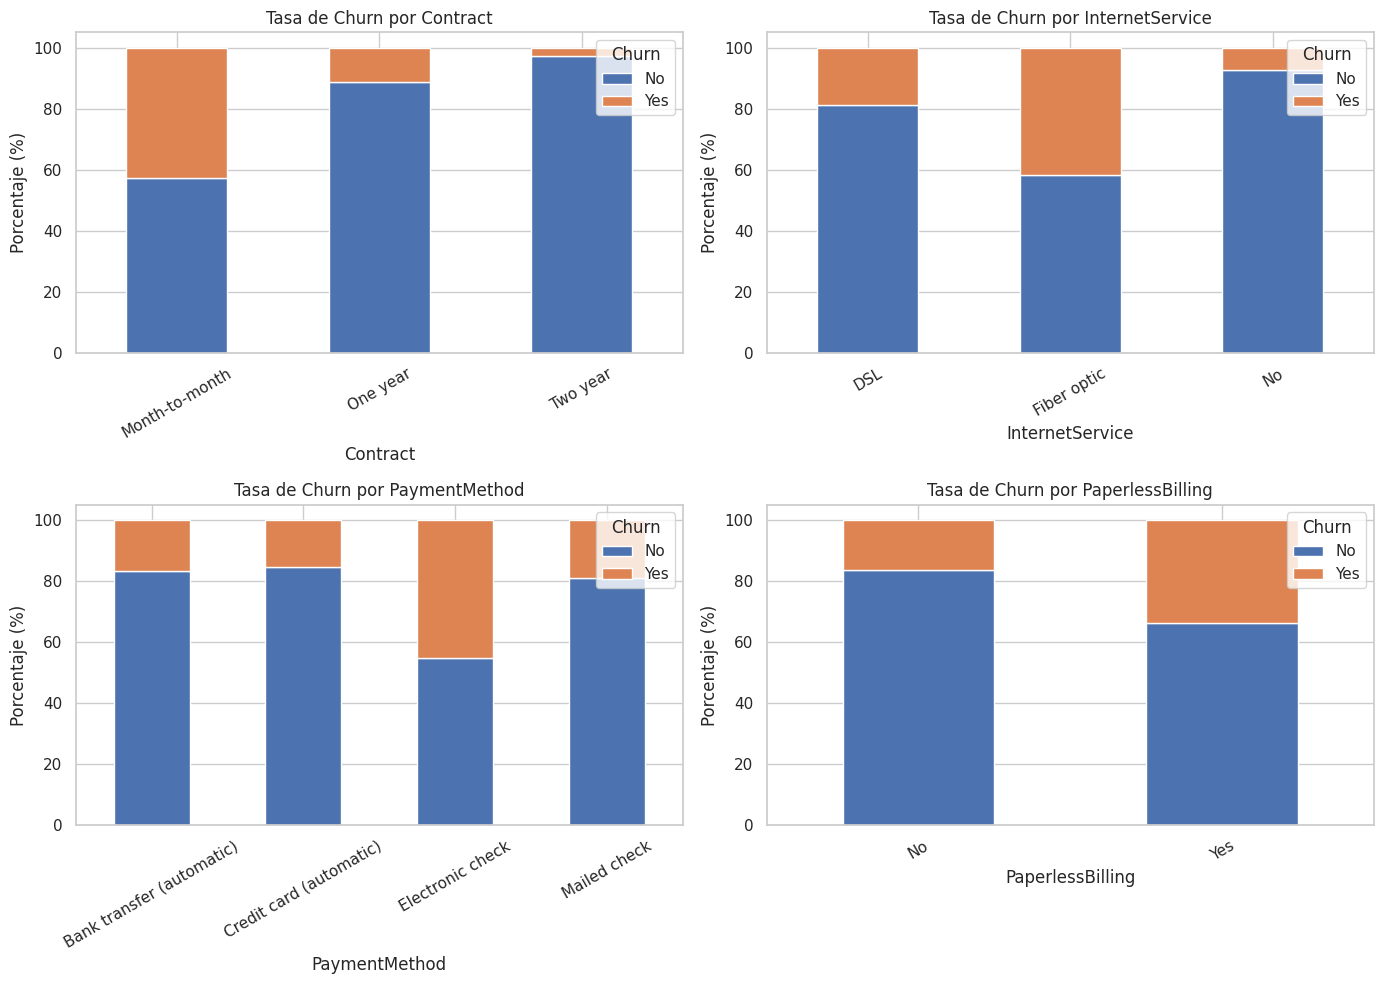

In [15]:
variables_categoricas_clave = ['Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(variables_categoricas_clave):
    tabla = pd.crosstab(df[var], df['Churn'], normalize='index') * 100
    tabla.plot(kind='bar', stacked=True, ax=axes[i], color=['#4C72B0', '#DD8452'])
    axes[i].set_title(f'Tasa de Churn por {var}')
    axes[i].set_ylabel('Porcentaje (%)')
    axes[i].legend(title='Churn', loc='upper right')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('/content/figuras/3.1.4_d_categoricas_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.4 Matriz de correlación (variables numéricas)

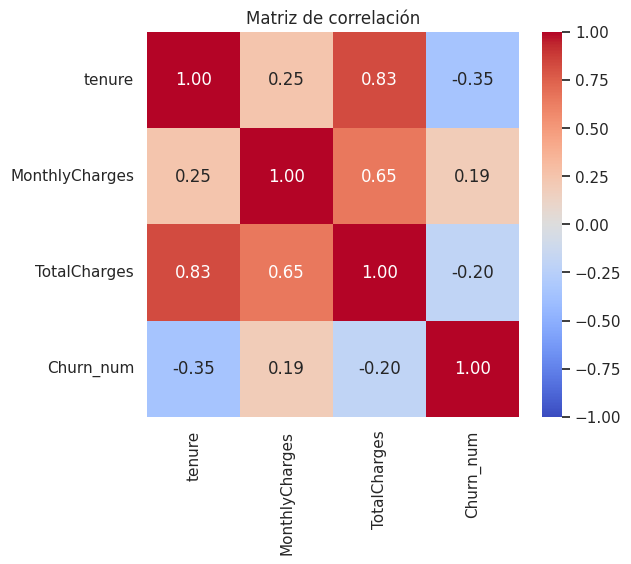

In [16]:
df_temp['Churn_num'] = df_temp['Churn'].map({'Yes': 1, 'No': 0})
matriz_corr = df_temp[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de correlación')
plt.savefig('/content/figuras/3.1.4_e_matriz_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.5 Descarga de las figuras generadas

Las cinco figuras anteriores se guardaron automáticamente en `/content/figuras/` con nombres que coinciden con los placeholders de la Sección 3.1.4 del informe (`3.1.4_a_...` a `3.1.4_e_...`). La siguiente celda las comprime en un único archivo `.zip` y lo descarga, para insertarlas directamente en Word sin necesidad de capturas de pantalla.

In [17]:
import shutil
from google.colab import files

ruta_zip = shutil.make_archive('/content/figuras_informe', 'zip', '/content/figuras')
files.download(ruta_zip)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 4. Limpieza de datos

### 4.1 Corrección de `TotalCharges`

Se imputan con 0 los 11 registros vacíos, correspondientes a clientes con `tenure = 0` (sin facturación acumulada aún). Esta imputación refleja la realidad del dato, a diferencia de una imputación estadística (media/mediana).

In [18]:
df_clean = df.copy()

df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

print(f"Registros con TotalCharges nulo antes de imputar: {df_clean['TotalCharges'].isna().sum()}")
print(f"Todos corresponden a tenure = 0: {(df_clean.loc[df_clean['TotalCharges'].isna(), 'tenure'] == 0).all()}")

df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)

print(f"Registros con TotalCharges nulo después de imputar: {df_clean['TotalCharges'].isna().sum()}")


Registros con TotalCharges nulo antes de imputar: 11
Todos corresponden a tenure = 0: True
Registros con TotalCharges nulo después de imputar: 0


### 4.2 Verificación de duplicados y eliminación del identificador

In [19]:
print(f"customerID duplicados: {df_clean['customerID'].duplicated().sum()}")

# customerID no aporta valor predictivo; se elimina antes del modelado.
df_clean = df_clean.drop(columns=['customerID'])


customerID duplicados: 0


## 5. Codificación de variables categóricas

### 5.1 Variables binarias (mapeo directo 0/1)

In [20]:
variables_binarias = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for var in variables_binarias:
    print(f"{var}: {df_clean[var].unique()}")


Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
PaperlessBilling: ['Yes' 'No']
Churn: ['No' 'Yes']


In [21]:
mapeo_binario = {'Yes': 1, 'No': 0}

for var in variables_binarias:
    df_clean[var] = df_clean[var].map(mapeo_binario)

df_clean['gender'] = df_clean['gender'].map({'Male': 1, 'Female': 0})

df_clean[variables_binarias + ['gender']].head()


,Partner,Dependents,PhoneService,PaperlessBilling,Churn,gender
0,1,0,0,1,0,0
1,0,0,1,0,0,1
2,0,0,1,1,1,1
3,0,0,0,0,0,1
4,0,0,1,1,1,0


### 5.2 Variables nominales con más de dos categorías (One-Hot Encoding)

In [22]:
variables_nominales = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

# drop_first=True evita la trampa de la variable dummy (colinealidad perfecta).
df_encoded = pd.get_dummies(df_clean, columns=variables_nominales, drop_first=True)

print(f"Dimensiones antes del One-Hot Encoding: {df_clean.shape}")
print(f"Dimensiones después del One-Hot Encoding: {df_encoded.shape}")
df_encoded.head()


Dimensiones antes del One-Hot Encoding: (7043, 20)
Dimensiones después del One-Hot Encoding: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


## 6. Escalado de variables numéricas

El escalado se aplica únicamente para la Regresión Logística; Random Forest y XGBoost no lo requieren. Se genera más adelante, una vez definida la partición de entrenamiento y prueba, para que el escalador se ajuste (`fit`) solo sobre el conjunto de entrenamiento.

## 7. Partición de los datos: entrenamiento, prueba y validación cruzada

### 7.1 División entrenamiento / prueba (80% / 20%, estratificada)

In [23]:
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Tamaño de entrenamiento: {X_train.shape[0]} registros")
print(f"Tamaño de prueba: {X_test.shape[0]} registros")
print("\nProporción de Churn en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))
print("\nProporción de Churn en prueba:")
print(y_test.value_counts(normalize=True).round(3))


Tamaño de entrenamiento: 5634 registros
Tamaño de prueba: 1409 registros

Proporción de Churn en entrenamiento:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

Proporción de Churn en prueba:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


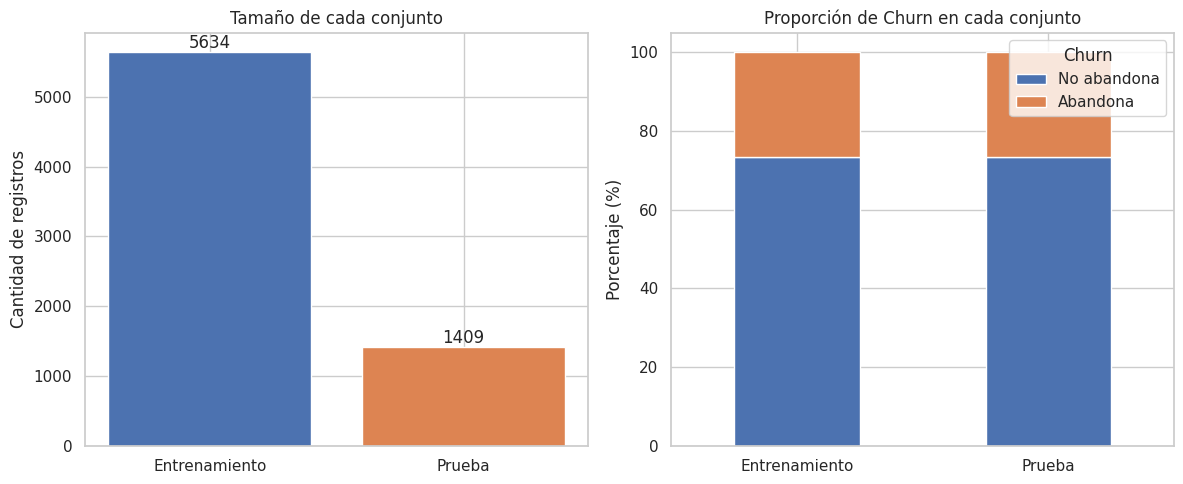

In [24]:
# Verificación visual de cómo quedó cada conjunto tras la partición.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

tamanos = pd.Series({'Entrenamiento': len(X_train), 'Prueba': len(X_test)})
barras_tam = axes[0].bar(tamanos.index, tamanos.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Tamaño de cada conjunto')
axes[0].set_ylabel('Cantidad de registros')
axes[0].bar_label(barras_tam)

proporciones = pd.DataFrame({
    'Entrenamiento': y_train.value_counts(normalize=True) * 100,
    'Prueba': y_test.value_counts(normalize=True) * 100,
}).T
proporciones.columns = ['No abandona', 'Abandona']
proporciones.plot(kind='bar', stacked=True, ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Proporción de Churn en cada conjunto')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Churn')

plt.tight_layout()
plt.savefig('/content/figuras/3.3_a_conjuntos_train_test.png', dpi=150, bbox_inches='tight')
plt.show()


In [25]:
variables_numericas_escalar = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[variables_numericas_escalar] = scaler.fit_transform(X_train[variables_numericas_escalar])
X_test_scaled[variables_numericas_escalar] = scaler.transform(X_test[variables_numericas_escalar])

print("Escalado aplicado. Estadísticos de las variables escaladas (entrenamiento):")
X_train_scaled[variables_numericas_escalar].describe().round(2)


Escalado aplicado. Estadísticos de las variables escaladas (entrenamiento):


,tenure,MonthlyCharges,TotalCharges
count,5634.00,5634.00,5634.00
mean,-0.00,-0.00,0.00
std,1.00,1.00,1.00
min,-1.32,-1.54,-1.01
25%,-0.96,-0.97,-0.83
50%,-0.14,0.18,-0.40
75%,0.92,0.83,0.67
max,1.61,1.79,2.80


### 7.2 Validación cruzada estratificada (5 pliegues)

In [26]:
cv_estratificada = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for i, (idx_train, idx_val) in enumerate(cv_estratificada.split(X_train, y_train)):
    proporcion = y_train.iloc[idx_val].mean()
    print(f"Pliegue {i+1}: {len(idx_val)} registros de validación, proporción de Churn = {proporcion:.3f}")


Pliegue 1: 1127 registros de validación, proporción de Churn = 0.265
Pliegue 2: 1127 registros de validación, proporción de Churn = 0.265
Pliegue 3: 1127 registros de validación, proporción de Churn = 0.265
Pliegue 4: 1127 registros de validación, proporción de Churn = 0.265
Pliegue 5: 1126 registros de validación, proporción de Churn = 0.266


## 8. Conclusiones

Al finalizar esta etapa se cuenta con:

- [ ] `X_train`, `X_test`, `y_train`, `y_test`: conjuntos sin escalar, listos para Random Forest y XGBoost.
- [ ] `X_train_scaled`, `X_test_scaled`: conjuntos escalados, listos para Regresión Logística.
- [ ] `cv_estratificada`: esquema de validación cruzada de 5 pliegues, reutilizable para los tres modelos.
- [ ] Dataset limpio, sin duplicados, sin valores nulos, con variables categóricas codificadas.
- [ ] Gráficos del EDA guardados en `/content/figuras/` para incorporar al informe (Sección III).

## 9. Modelos de Machine Learning: implementación base

Se entrenan los tres modelos candidatos con hiperparámetros base, sin optimización (la búsqueda de hiperparámetros corresponde a la siguiente fase del proyecto). El objetivo de esta sección es verificar el correcto funcionamiento del flujo de entrenamiento y obtener una primera referencia de desempeño.

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# scale_pos_weight de XGBoost: razón entre clase negativa y positiva en el
# conjunto de entrenamiento, equivalente conceptual a class_weight='balanced'.
proporcion_negativo_positivo = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight calculado: {proporcion_negativo_positivo:.3f}")


scale_pos_weight calculado: 2.769


### 9.1 Regresión Logística (baseline)

In [28]:
modelo_lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)
modelo_lr.fit(X_train_scaled, y_train)

pred_lr = modelo_lr.predict(X_test_scaled)
proba_lr = modelo_lr.predict_proba(X_test_scaled)[:, 1]

print("Regresión Logística (baseline) entrenada correctamente.")


Regresión Logística (baseline) entrenada correctamente.


### 9.2 Random Forest (baseline)

In [29]:
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)
proba_rf = modelo_rf.predict_proba(X_test)[:, 1]

print("Random Forest (baseline) entrenado correctamente.")


Random Forest (baseline) entrenado correctamente.


### 9.3 XGBoost (baseline)

In [30]:
modelo_xgb = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=proporcion_negativo_positivo,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
modelo_xgb.fit(X_train, y_train)

pred_xgb = modelo_xgb.predict(X_test)
proba_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

print("XGBoost (baseline) entrenado correctamente.")


XGBoost (baseline) entrenado correctamente.


### 9.4 Comparación preliminar de resultados baseline

Esta comparación es únicamente preliminar y orientativa; la evaluación formal, con hiperparámetros optimizados y análisis detallado de métricas, se desarrolla en las fases posteriores del proyecto.

In [31]:
resultados_baseline = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_xgb),
    ],
    'Precision': [
        precision_score(y_test, pred_lr),
        precision_score(y_test, pred_rf),
        precision_score(y_test, pred_xgb),
    ],
    'Recall': [
        recall_score(y_test, pred_lr),
        recall_score(y_test, pred_rf),
        recall_score(y_test, pred_xgb),
    ],
    'F1-score': [
        f1_score(y_test, pred_lr),
        f1_score(y_test, pred_rf),
        f1_score(y_test, pred_xgb),
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, proba_lr),
        roc_auc_score(y_test, proba_rf),
        roc_auc_score(y_test, proba_xgb),
    ],
}).round(3)

resultados_baseline


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regresión Logística,0.738,0.504,0.783,0.614,0.842
1,Random Forest,0.788,0.630,0.487,0.549,0.829
2,XGBoost,0.757,0.536,0.618,0.574,0.812


## 10. Agente de Utilidad: implementación

Se implementa el agente descrito en la Sección 4.1.2 del informe: dada la probabilidad de abandono de un cliente y su valor estimado, el agente calcula la utilidad esperada de cada acción de retención disponible y recomienda la de mayor utilidad esperada.

**Advertencia metodológica:** los valores de efectividad `e(a)` y costo `c(a)` de cada acción son supuestos de negocio razonables, no estimaciones derivadas de un experimento controlado (el dataset no contiene resultados históricos de campañas de retención). Deben tratarse como parámetros configurables, ajustables por el equipo de negocio.

### 10.1 Definición de las acciones de retención

In [32]:
HORIZONTE_MESES = 12  # horizonte de retención asumido para estimar el valor del cliente (CLV proxy)

# Cada acción define su efectividad estimada e(a) y una función de costo c(a)
# que depende del cargo mensual del cliente cuando corresponde.
ACCIONES = {
    'Sin accion': {
        'efectividad': 0.00,
        'costo': lambda cargo_mensual: 0.0,
    },
    'Descuento en la tarifa': {
        'efectividad': 0.35,
        'costo': lambda cargo_mensual: 0.20 * cargo_mensual * HORIZONTE_MESES,
    },
    'Mejora de plan sin costo adicional': {
        'efectividad': 0.45,
        'costo': lambda cargo_mensual: 120.0,  # costo fijo estimado
    },
    'Contacto proactivo': {
        'efectividad': 0.15,
        'costo': lambda cargo_mensual: 5.0,  # costo operativo bajo
    },
}

for accion, params in ACCIONES.items():
    print(f"{accion}: efectividad={params['efectividad']:.0%}")


Sin accion: efectividad=0%
Descuento en la tarifa: efectividad=35%
Mejora de plan sin costo adicional: efectividad=45%
Contacto proactivo: efectividad=15%


### 10.2 Función de utilidad y regla de decisión

In [33]:
def calcular_utilidad(probabilidad_churn, cargo_mensual, accion):
    """
    Calcula la utilidad esperada U(a) = p * e(a) * V - c(a) de aplicar una
    acción de retención sobre un cliente.

    Parámetros
    ----------
    probabilidad_churn : float
        Probabilidad estimada de abandono (p), entre 0 y 1.
    cargo_mensual : float
        Cargo mensual del cliente, usado como base para estimar su valor (V)
        y, en algunas acciones, el costo de la intervención.
    accion : str
        Nombre de la acción, debe existir en el diccionario ACCIONES.

    Retorna
    -------
    float : utilidad esperada de la acción.
    """
    valor_cliente = cargo_mensual * HORIZONTE_MESES
    efectividad = ACCIONES[accion]['efectividad']
    costo = ACCIONES[accion]['costo'](cargo_mensual)
    return probabilidad_churn * efectividad * valor_cliente - costo


def recomendar_accion(probabilidad_churn, cargo_mensual):
    """
    Agente de utilidad: evalúa todas las acciones disponibles y devuelve
    la de mayor utilidad esperada, junto con el detalle de todas las opciones.
    """
    utilidades = {
        accion: calcular_utilidad(probabilidad_churn, cargo_mensual, accion)
        for accion in ACCIONES
    }
    mejor_accion = max(utilidades, key=utilidades.get)
    return mejor_accion, utilidades


# Prueba unitaria simple de la función con un cliente de alto riesgo
accion, detalle = recomendar_accion(probabilidad_churn=0.8, cargo_mensual=90)
print(f"Acción recomendada: {accion}")
for a, u in detalle.items():
    print(f"  {a}: utilidad esperada = {u:.2f}")


Acción recomendada: Mejora de plan sin costo adicional
  Sin accion: utilidad esperada = 0.00
  Descuento en la tarifa: utilidad esperada = 86.40
  Mejora de plan sin costo adicional: utilidad esperada = 268.80
  Contacto proactivo: utilidad esperada = 124.60


### 10.3 Prueba del agente sobre clientes del conjunto de prueba

In [34]:
# Se emplea XGBoost (mejor resultado preliminar en la Sección 9.4) para estimar
# la probabilidad de abandono de una muestra de clientes del conjunto de prueba.
muestra = X_test.sample(10, random_state=RANDOM_STATE)
proba_muestra = modelo_xgb.predict_proba(muestra)[:, 1]

resultados_agente = []
for idx, prob in zip(muestra.index, proba_muestra):
    cargo_mensual = X_test.loc[idx, 'MonthlyCharges']
    accion, _ = recomendar_accion(prob, cargo_mensual)
    resultados_agente.append({
        'Probabilidad de abandono': round(prob, 3),
        'Cargo mensual': round(cargo_mensual, 2),
        'Acción recomendada': accion,
    })

pd.DataFrame(resultados_agente)


,Probabilidad de abandono,Cargo mensual,Acción recomendada
0,0.072,50.85,Contacto proactivo
1,0.361,50.30,Contacto proactivo
2,0.000,19.45,Sin accion
3,0.827,79.85,Mejora de plan sin costo adicional
4,0.002,63.30,Sin accion
5,0.001,19.95,Sin accion
6,0.070,113.75,Contacto proactivo
7,0.108,49.55,Contacto proactivo
8,0.425,51.35,Contacto proactivo
9,0.987,102.45,Mejora de plan sin costo adicional


## 11. Conclusiones de la Fase 4

- [ ] Los tres modelos candidatos (Regresión Logística, Random Forest, XGBoost) fueron implementados con hiperparámetros base y evaluados de forma preliminar.
- [ ] El Agente de Utilidad fue implementado como una función pura, parametrizable, que recibe la probabilidad de abandono y el cargo mensual del cliente y devuelve la acción de retención con mayor utilidad esperada.
- [ ] Se validó el flujo completo del sistema: predicción del modelo → cálculo de utilidad por acción → recomendación.

**Siguiente paso:** búsqueda de hiperparámetros y entrenamiento formal de los tres modelos mediante validación cruzada.

## 12. Búsqueda de hiperparámetros y entrenamiento formal

### 12.1 Criterio de optimización

Los resultados baseline de la Sección 9.4 mostraron que Random Forest (Recall = 0.487) y XGBoost (Recall = 0.618) quedan por debajo del umbral mínimo de Recall (70%) establecido como requisito no funcional del proyecto. Optimizar la búsqueda de hiperparámetros por Accuracy —el criterio por defecto— no corrige este problema, ya que la Accuracy está dominada por la clase mayoritaria (clientes que no abandonan).

Se adopta como criterio de optimización el **F2-score**, una variante del F1-score que pondera el Recall el doble que la Precision (β=2). Se prefiere el F2-score sobre optimizar directamente por Recall, porque este último puede degenerar en un modelo que clasifica a todos los clientes como abandono (Recall = 1.0 con Precision cercana a 0, lo cual carece de utilidad práctica). El F2-score refleja el costo asimétrico de los falsos negativos discutido en los antecedentes del proyecto, sin caer en esa solución degenerada.

In [35]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer, fbeta_score

# F2-score: pondera el Recall el doble que la Precision (beta=2)
f2_scorer = make_scorer(fbeta_score, beta=2)


### 12.1bis Persistencia de modelos (evitar reejecutar la búsqueda)

`GridSearchCV` y `RandomizedSearchCV` son computacionalmente costosos, y el almacenamiento local de Colab (`/content/...`) se borra al reiniciar el entorno de ejecución. Para no tener que reejecutar la búsqueda de hiperparámetros cada vez, los mejores modelos se guardan en Google Drive con `joblib`. Cada celda de búsqueda de esta sección primero intenta cargar el modelo ya guardado; solo si no lo encuentra, ejecuta la búsqueda desde cero y luego lo guarda.

In [36]:
import joblib
import os

from google.colab import drive
drive.mount('/content/drive')  # si ya está montado, esta llamada no hace nada

# Ajustar esta ruta a la carpeta del proyecto en el Drive del equipo
RUTA_MODELOS = '/content/drive/MyDrive/RUTA_DEL_PROYECTO/modelos'
os.makedirs(RUTA_MODELOS, exist_ok=True)

print(f"Los modelos se guardarán/cargarán desde: {RUTA_MODELOS}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Los modelos se guardarán/cargarán desde: /content/drive/MyDrive/RUTA_DEL_PROYECTO/modelos


### 12.2 Regresión Logística (GridSearchCV)

Al tratarse de un espacio de hiperparámetros pequeño, se emplea GridSearchCV (búsqueda exhaustiva), que es computacionalmente viable en este caso y garantiza evaluar todas las combinaciones.

In [37]:
ruta_lr = f'{RUTA_MODELOS}/modelo_lr_final.joblib'

if os.path.exists(ruta_lr):
    modelo_lr_final = joblib.load(ruta_lr)
    print("Modelo cargado desde Drive (no se reejecutó GridSearchCV).")
else:
    grid_lr = {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs'],
    }

    busqueda_lr = GridSearchCV(
        estimator=LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
        param_grid=grid_lr,
        scoring=f2_scorer,
        cv=cv_estratificada,
        n_jobs=-1
    )
    busqueda_lr.fit(X_train_scaled, y_train)

    print(f"Mejores hiperparámetros: {busqueda_lr.best_params_}")
    print(f"Mejor F2-score (validación cruzada): {busqueda_lr.best_score_:.3f}")

    modelo_lr_final = busqueda_lr.best_estimator_
    joblib.dump(modelo_lr_final, ruta_lr)
    print("Modelo guardado en Drive.")


Mejores hiperparámetros: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Mejor F2-score (validación cruzada): 0.723
Modelo guardado en Drive.


### 12.3 Random Forest (RandomizedSearchCV)

El espacio de hiperparámetros de Random Forest es considerablemente más grande. RandomizedSearchCV explora una muestra aleatoria de combinaciones en lugar de todas, lo que reduce el costo computacional a cambio de no garantizar encontrar el óptimo global; en la práctica, para espacios grandes, ofrece resultados comparables a una búsqueda exhaustiva con una fracción del costo.

In [38]:
ruta_rf = f'{RUTA_MODELOS}/modelo_rf_final.joblib'

if os.path.exists(ruta_rf):
    modelo_rf_final = joblib.load(ruta_rf)
    print("Modelo cargado desde Drive (no se reejecutó RandomizedSearchCV).")
else:
    distribucion_rf = {
        'n_estimators': [100, 200, 300, 400],
        'max_depth': [None, 10, 20, 30],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2'],
    }

    busqueda_rf = RandomizedSearchCV(
        estimator=RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
        param_distributions=distribucion_rf,
        n_iter=20,
        scoring=f2_scorer,
        cv=cv_estratificada,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    busqueda_rf.fit(X_train, y_train)

    print(f"Mejores hiperparámetros: {busqueda_rf.best_params_}")
    print(f"Mejor F2-score (validación cruzada): {busqueda_rf.best_score_:.3f}")

    modelo_rf_final = busqueda_rf.best_estimator_
    joblib.dump(modelo_rf_final, ruta_rf)
    print("Modelo guardado en Drive.")


Mejores hiperparámetros: {'n_estimators': 200, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}
Mejor F2-score (validación cruzada): 0.696
Modelo guardado en Drive.


### 12.4 XGBoost (RandomizedSearchCV)

In [39]:
ruta_xgb = f'{RUTA_MODELOS}/modelo_xgb_final.joblib'

if os.path.exists(ruta_xgb):
    modelo_xgb_final = joblib.load(ruta_xgb)
    print("Modelo cargado desde Drive (no se reejecutó RandomizedSearchCV).")
else:
    distribucion_xgb = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
    }

    busqueda_xgb = RandomizedSearchCV(
        estimator=XGBClassifier(
            scale_pos_weight=proporcion_negativo_positivo,
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        param_distributions=distribucion_xgb,
        n_iter=20,
        scoring=f2_scorer,
        cv=cv_estratificada,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    busqueda_xgb.fit(X_train, y_train)

    print(f"Mejores hiperparámetros: {busqueda_xgb.best_params_}")
    print(f"Mejor F2-score (validación cruzada): {busqueda_xgb.best_score_:.3f}")

    modelo_xgb_final = busqueda_xgb.best_estimator_
    joblib.dump(modelo_xgb_final, ruta_xgb)
    print("Modelo guardado en Drive.")


Mejores hiperparámetros: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Mejor F2-score (validación cruzada): 0.733
Modelo guardado en Drive.


### 12.5 Aplicación de los modelos finales sobre el conjunto de prueba

In [40]:
# Los estimadores finales (best_estimator_) ya quedaron reentrenados sobre todo
# el conjunto de entrenamiento con los mejores hiperparámetros encontrados.
# Se generan las predicciones sobre el conjunto de prueba, reservado y no
# utilizado en ninguna etapa de la búsqueda de hiperparámetros.

pred_lr_final = modelo_lr_final.predict(X_test_scaled)
proba_lr_final = modelo_lr_final.predict_proba(X_test_scaled)[:, 1]

pred_rf_final = modelo_rf_final.predict(X_test)
proba_rf_final = modelo_rf_final.predict_proba(X_test)[:, 1]

pred_xgb_final = modelo_xgb_final.predict(X_test)
proba_xgb_final = modelo_xgb_final.predict_proba(X_test)[:, 1]

print("Predicciones generadas sobre el conjunto de prueba para los tres modelos ajustados.")


Predicciones generadas sobre el conjunto de prueba para los tres modelos ajustados.


### 12.6 Comparación de modelos ajustados vs. baseline

In [41]:
resultados_finales = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, pred_lr_final),
        accuracy_score(y_test, pred_rf_final),
        accuracy_score(y_test, pred_xgb_final),
    ],
    'Precision': [
        precision_score(y_test, pred_lr_final),
        precision_score(y_test, pred_rf_final),
        precision_score(y_test, pred_xgb_final),
    ],
    'Recall': [
        recall_score(y_test, pred_lr_final),
        recall_score(y_test, pred_rf_final),
        recall_score(y_test, pred_xgb_final),
    ],
    'F1-score': [
        f1_score(y_test, pred_lr_final),
        f1_score(y_test, pred_rf_final),
        f1_score(y_test, pred_xgb_final),
    ],
    'F2-score': [
        fbeta_score(y_test, pred_lr_final, beta=2),
        fbeta_score(y_test, pred_rf_final, beta=2),
        fbeta_score(y_test, pred_xgb_final, beta=2),
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, proba_lr_final),
        roc_auc_score(y_test, proba_rf_final),
        roc_auc_score(y_test, proba_xgb_final),
    ],
}).round(3)

print("Modelos ajustados (después de la búsqueda de hiperparámetros):")
display(resultados_finales)

print("\nRecordatorio — resultados baseline (Sección 9.4), para comparar:")
display(resultados_baseline)


Modelos ajustados (después de la búsqueda de hiperparámetros):


,Modelo,Accuracy,Precision,Recall,F1-score,F2-score,ROC-AUC
0,Regresión Logística,0.738,0.504,0.783,0.614,0.705,0.842
1,Random Forest,0.767,0.544,0.757,0.633,0.702,0.844
2,XGBoost,0.747,0.515,0.816,0.631,0.730,0.846



Recordatorio — resultados baseline (Sección 9.4), para comparar:


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regresión Logística,0.738,0.504,0.783,0.614,0.842
1,Random Forest,0.788,0.630,0.487,0.549,0.829
2,XGBoost,0.757,0.536,0.618,0.574,0.812


## 13. Conclusiones de la Fase 5

- [ ] Se definió el F2-score como criterio de optimización de la búsqueda de hiperparámetros, alineado con el costo asimétrico de los falsos negativos.
- [ ] Se aplicó GridSearchCV para Regresión Logística (espacio pequeño) y RandomizedSearchCV para Random Forest y XGBoost (espacios grandes), justificando la elección por el tamaño del espacio de búsqueda.
- [ ] Los tres modelos fueron reentrenados con sus mejores hiperparámetros sobre el conjunto de entrenamiento completo.
- [ ] Se generaron las predicciones finales sobre el conjunto de prueba, no utilizado en ninguna etapa de la búsqueda de hiperparámetros.
- [ ] Se comparó el desempeño de los modelos ajustados frente a los modelos baseline, verificando si el ajuste de hiperparámetros permitió alcanzar el umbral mínimo de Recall (70%) establecido como requisito.

## 14. Evaluación del modelo predictivo

### 14.1 Selección del modelo final

De los tres modelos ajustados, XGBoost obtuvo el mejor F2-score (0.730), el mejor ROC-AUC (0.846) y el segundo mejor Recall (0.816, solo superado marginalmente por sí mismo). Random Forest quedó muy cerca en F2-score (0.702) pero con menor Recall (0.757). Regresión Logística, si bien es el modelo más interpretable por naturaleza, obtuvo el menor F2-score (0.705). Se selecciona **XGBoost** como modelo final del sistema.

In [42]:
modelo_final = modelo_xgb_final
pred_final = pred_xgb_final
proba_final = proba_xgb_final

print("Modelo final seleccionado: XGBoost")
print(resultados_finales[resultados_finales['Modelo'] == 'XGBoost'])


Modelo final seleccionado: XGBoost
    Modelo  Accuracy  Precision  Recall  F1-score  F2-score  ROC-AUC
2  XGBoost     0.747      0.515   0.816     0.631      0.73    0.846


### 14.2 Matriz de confusión

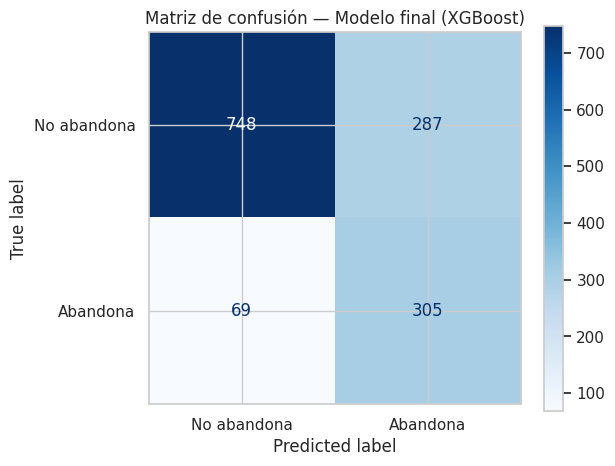

Verdaderos negativos: 748 | Falsos positivos: 287
Falsos negativos: 69 | Verdaderos positivos: 305


In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

matriz = confusion_matrix(y_test, pred_final)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['No abandona', 'Abandona'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Matriz de confusión — Modelo final (XGBoost)')
plt.savefig('/content/figuras/6.1_a_matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

vn, fp, fn, vp = matriz.ravel()
print(f"Verdaderos negativos: {vn} | Falsos positivos: {fp}")
print(f"Falsos negativos: {fn} | Verdaderos positivos: {vp}")


### 14.3 Curva ROC y curva Precision-Recall (comparación de los tres modelos)

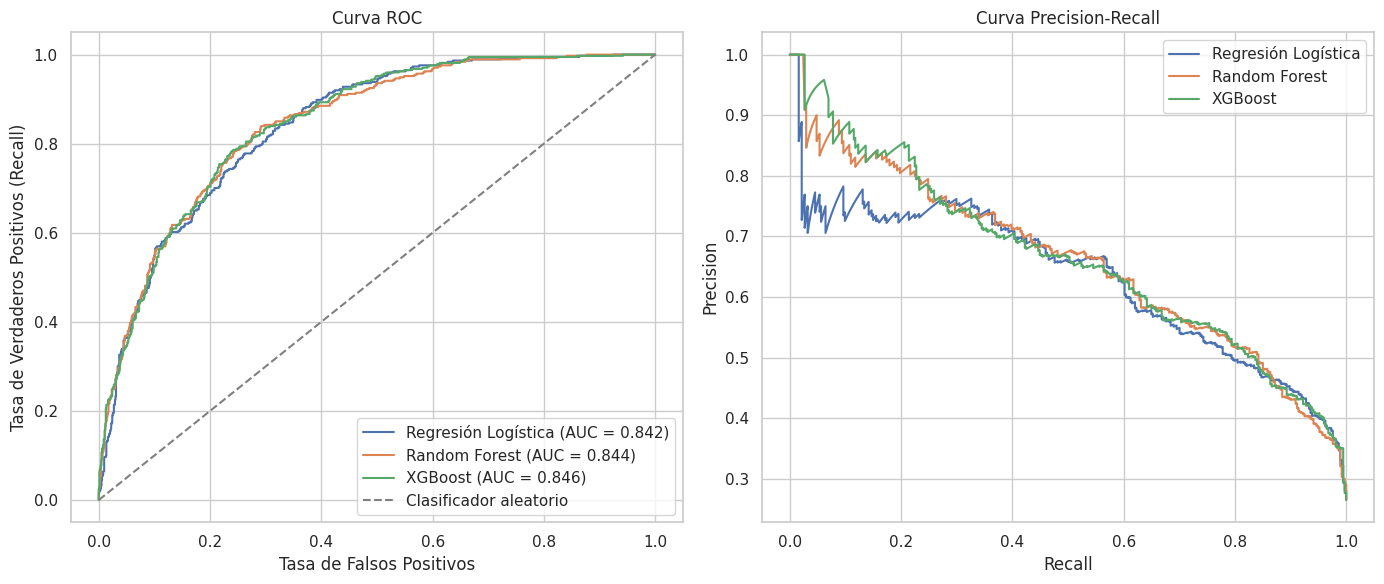

In [44]:
from sklearn.metrics import roc_curve, precision_recall_curve

modelos_proba = {
    'Regresión Logística': proba_lr_final,
    'Random Forest': proba_rf_final,
    'XGBoost': proba_xgb_final,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for nombre, proba in modelos_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.3f})')

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Clasificador aleatorio')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
axes[0].set_title('Curva ROC')
axes[0].legend()

for nombre, proba in modelos_proba.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(recall, precision, label=nombre)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/figuras/6.1_b_curvas_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()


### 14.4 Interpretabilidad: importancia de variables y valores SHAP

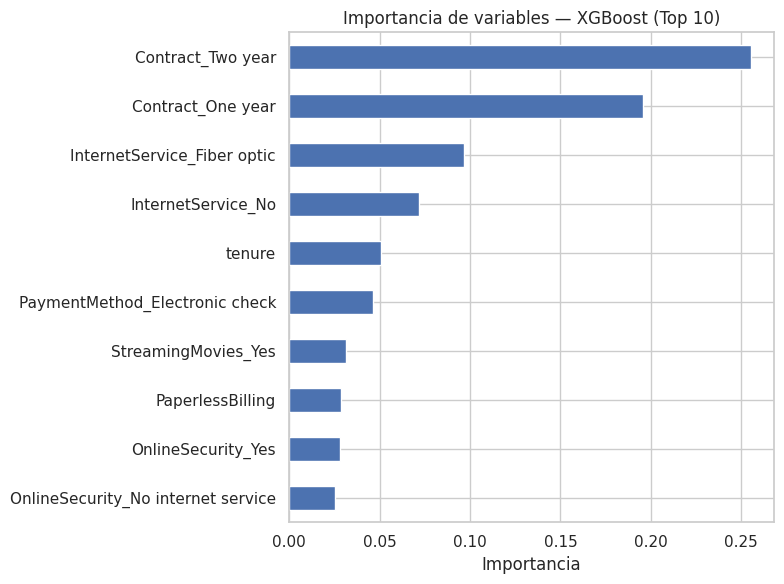

In [45]:
importancias = pd.Series(modelo_final.feature_importances_, index=X_train.columns)
importancias_top = importancias.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
importancias_top.sort_values().plot(kind='barh', color='#4C72B0')
plt.title('Importancia de variables — XGBoost (Top 10)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('/content/figuras/6.1_c_importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()


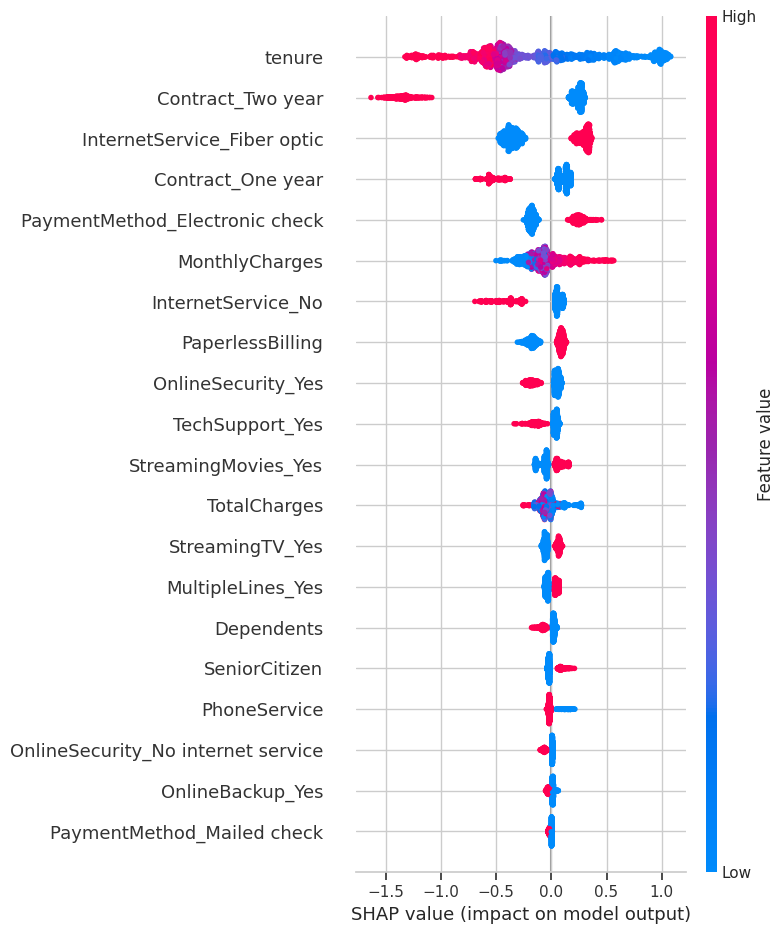

In [46]:
import shap

explainer = shap.TreeExplainer(modelo_final)
valores_shap = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(valores_shap, X_test, show=False)
plt.tight_layout()
plt.savefig('/content/figuras/6.1_d_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


### 14.5 Contraste con la literatura revisada

El modelo final (XGBoost) alcanzó un ROC-AUC de 0.846 sobre el conjunto de prueba, valor inferior al 0.932 reportado por El Attar y El-Hajj (2026) empleando el mismo conjunto de datos. Entre las posibles causas de esta diferencia se encuentran: (a) diferencias en la partición train/test empleada, (b) el criterio de optimización de hiperparámetros priorizado (F2-score, orientado a maximizar Recall, frente a un criterio que podría haber priorizado directamente el AUC-ROC), y (c) posibles diferencias en el tratamiento del desbalance de clases (el estudio de referencia no detalla si excluye SMOTE de forma estricta del conjunto de prueba). Esta comparación se documenta con fines de contextualización, no de replicación exacta, dado que ninguno de los dos estudios comparte el código fuente completo del preprocesamiento aplicado.

## 15. Evaluación de desempeño del sistema completo

Además de evaluar el modelo predictivo de forma aislada, se evalúa el sistema completo (modelo + Agente de Utilidad) comparando la utilidad total esperada de la política de decisión del agente —una acción distinta y personalizada por cliente— frente a políticas de referencia más simples: no intervenir con ningún cliente, o aplicar la misma acción a todos los clientes del conjunto de prueba, independientemente de su riesgo individual.

In [47]:
# Probabilidad de abandono estimada por el modelo final para todo el conjunto de prueba
proba_test_final = modelo_final.predict_proba(X_test)[:, 1]
cargos_test = X_test['MonthlyCharges']

def utilidad_total_politica(politica):
    """
    Calcula la utilidad total esperada del conjunto de prueba bajo una política.
    politica: función que recibe (probabilidad, cargo_mensual) y devuelve una acción,
              o un string fijo si la política aplica siempre la misma acción.
    """
    total = 0.0
    for prob, cargo in zip(proba_test_final, cargos_test):
        accion = politica if isinstance(politica, str) else politica(prob, cargo)
        total += calcular_utilidad(prob, cargo, accion)
    return total


politicas = {
    'Agente de Utilidad (personalizado)': lambda p, c: recomendar_accion(p, c)[0],
    'Sin intervención (para todos)': 'Sin accion',
    'Descuento (para todos)': 'Descuento en la tarifa',
    'Mejora de plan (para todos)': 'Mejora de plan sin costo adicional',
    'Contacto proactivo (para todos)': 'Contacto proactivo',
}

resultados_politicas = {nombre: utilidad_total_politica(pol) for nombre, pol in politicas.items()}

resultados_politicas_df = pd.DataFrame(
    sorted(resultados_politicas.items(), key=lambda x: x[1], reverse=True),
    columns=['Política', 'Utilidad total esperada (conjunto de prueba)']
).round(2)

resultados_politicas_df


,Política,Utilidad total esperada (conjunto de prueba)
0,Agente de Utilidad (personalizado),123427.156250
1,Contacto proactivo (para todos),68943.179688
2,Mejora de plan (para todos),58884.558594
3,Sin intervención (para todos),0.000000
4,Descuento (para todos),-39417.101562


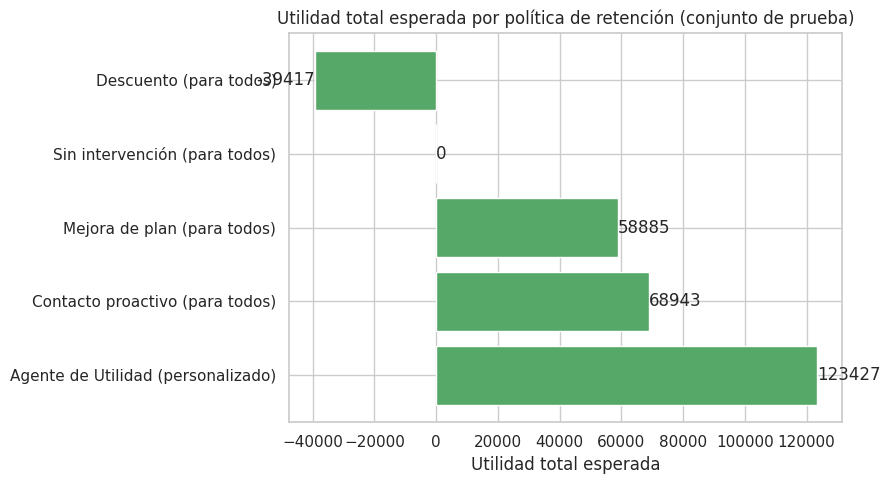

In [48]:
plt.figure(figsize=(9, 5))
barras = plt.barh(resultados_politicas_df['Política'], resultados_politicas_df['Utilidad total esperada (conjunto de prueba)'], color='#55A868')
plt.xlabel('Utilidad total esperada')
plt.title('Utilidad total esperada por política de retención (conjunto de prueba)')
plt.bar_label(barras, fmt='%.0f')
plt.tight_layout()
plt.savefig('/content/figuras/6.2_a_comparacion_politicas.png', dpi=150, bbox_inches='tight')
plt.show()


**Lectura esperada:** la política del Agente de Utilidad, al seleccionar la acción de mayor utilidad esperada para cada cliente de forma individual, debería superar a cualquier política que aplique una única acción de forma homogénea a todos los clientes. Esto ilustra cuantitativamente el valor agregado de la personalización frente a una estrategia de retención uniforme, que es precisamente la limitación identificada en el planteamiento del problema.

## 16. Conclusiones de la Fase 6

- [ ] Se seleccionó XGBoost como modelo final, con justificación basada en F2-score, Recall y ROC-AUC.
- [ ] Se generaron la matriz de confusión, las curvas ROC y Precision-Recall, y el análisis de importancia de variables (incluyendo SHAP) para el modelo final.
- [ ] Se contrastaron los resultados con el estudio de referencia que emplea el mismo dataset, documentando posibles causas de la diferencia observada.
- [ ] Se evaluó el sistema completo comparando la utilidad total esperada de la política del Agente de Utilidad frente a políticas de referencia homogéneas, cuantificando el valor de la personalización.

## 17. Exportación de artefactos para despliegue

El modelo final (XGBoost) ya se encuentra guardado en Drive desde la Sección 12 (`modelo_xgb_final.joblib`). Para desplegarlo como API, adicionalmente se necesita la lista exacta de columnas usadas en el entrenamiento (`X_train.columns`), ya que la API deberá reconstruir esas mismas columnas, en el mismo orden, a partir de los datos que ingrese un usuario nuevo.

**Nota importante:** el modelo final no requiere escalado de variables (XGBoost es invariante a la escala), por lo que no es necesario exportar el `StandardScaler`. Esto simplifica la API: solo se necesitan el modelo y la lista de columnas.

In [49]:
ruta_columnas = f'{RUTA_MODELOS}/columnas_modelo.joblib'

columnas_modelo = X_train.columns.tolist()
joblib.dump(columnas_modelo, ruta_columnas)

print(f"Se guardaron {len(columnas_modelo)} columnas en: {ruta_columnas}")
print("\nRecordatorio: para desplegar la API, descarga desde Drive los archivos")
print(f"  - {RUTA_MODELOS}/modelo_xgb_final.joblib")
print(f"  - {ruta_columnas}")
print("y colócalos en la carpeta api/modelo/ del repositorio de despliegue.")


Se guardaron 30 columnas en: /content/drive/MyDrive/RUTA_DEL_PROYECTO/modelos/columnas_modelo.joblib

Recordatorio: para desplegar la API, descarga desde Drive los archivos
  - /content/drive/MyDrive/RUTA_DEL_PROYECTO/modelos/modelo_xgb_final.joblib
  - /content/drive/MyDrive/RUTA_DEL_PROYECTO/modelos/columnas_modelo.joblib
y colócalos en la carpeta api/modelo/ del repositorio de despliegue.


In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
